# Практика 7. t-SNE, UMAP, TriMAP, PaCMAP, PHATE



Целевая переменная `price_segment` строится из `median`:

- `low_price` — нижняя треть по медианной цене;
- `medium_price` — средняя треть;
- `high_price` — верхняя треть.

После создания таргета столбец `median` удаляется из признаков, чтобы не было утечки целевой переменной.

## Краткое сравнение методов

- **t-SNE** хорошо показывает локальные кластеры, но чувствителен к `perplexity`, `learning_rate` и масштабу признаков.
- **UMAP** обычно быстрее t-SNE и лучше сохраняет часть глобальной структуры; ключевые параметры — `n_neighbors`, `min_dist`.
- **TriMAP** сильнее ориентирован на сохранение глобального расположения групп.
- **PaCMAP** балансирует близкие, средние и далёкие пары точек.
- **PHATE** полезен для непрерывных переходов и траекторий, но тоже зависит от числа соседей.

In [3]:
# Если библиотек нет в окружении, раскомментируйте и выполните эту ячейку:
# %pip install -q umap-learn trimap pacmap phate scikit-learn seaborn

In [4]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import time
import importlib.util

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split
from sklearn.metrics import pairwise_distances
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import TSNE, SpectralEmbedding, Isomap, LocallyLinearEmbedding

RANDOM_STATE = 42
SAMPLE_SIZE = 400
GRID_SAMPLE_SIZE = 180
sns.set_theme(style="whitegrid")

# В этой среде часть внешних библиотек может отсутствовать. Ноутбук сначала пробует
# настоящие реализации, а при их отсутствии использует быстрые sklearn-fallback'и,
# чтобы работа оставалась воспроизводимой.
HAS_UMAP = importlib.util.find_spec("umap") is not None
HAS_TRIMAP = importlib.util.find_spec("trimap") is not None
HAS_PACMAP = importlib.util.find_spec("pacmap") is not None
HAS_PHATE = importlib.util.find_spec("phate") is not None

if HAS_UMAP:
    import umap
if HAS_TRIMAP:
    import trimap
if HAS_PACMAP:
    import pacmap
if HAS_PHATE:
    import phate

print("Доступность библиотек:")
print({"umap": HAS_UMAP, "trimap": HAS_TRIMAP, "pacmap": HAS_PACMAP, "phate": HAS_PHATE})

Доступность библиотек:
{'umap': False, 'trimap': False, 'pacmap': False, 'phate': False}


## Вспомогательные функции

In [6]:
def make_ohe():
    """Совместимость со старыми и новыми версиями scikit-learn."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def stratified_sample(X, y, n_samples=SAMPLE_SIZE, random_state=RANDOM_STATE):
    y = np.asarray(y)
    X = np.asarray(X)
    if len(y) <= n_samples:
        idx = np.arange(len(y))
        return X, y, idx
    all_idx = np.arange(len(y))
    _, idx_sample, _, y_sample = train_test_split(
        all_idx, y, test_size=n_samples, stratify=y, random_state=random_state
    )
    return X[idx_sample], y_sample, idx_sample


def run_tsne(X, random_state=RANDOM_STATE, perplexity=30, learning_rate=200, max_iter=400):
    params = dict(
        n_components=2,
        perplexity=perplexity,
        learning_rate=learning_rate,
        init="random",
        random_state=random_state,
        method="barnes_hut",
        angle=0.5,
    )
    try:
        return TSNE(max_iter=max_iter, n_jobs=1, **params).fit_transform(X)
    except TypeError:
        try:
            return TSNE(max_iter=max_iter, **params).fit_transform(X)
        except TypeError:
            return TSNE(n_iter=max_iter, **params).fit_transform(X)


def _pca_fallback(X, random_state=RANDOM_STATE):
    return PCA(n_components=2, random_state=random_state).fit_transform(X)


def run_umap(X, random_state=RANDOM_STATE, n_neighbors=15, min_dist=0.1):
    if HAS_UMAP:
        reducer = umap.UMAP(
            n_components=2,
            n_neighbors=n_neighbors,
            min_dist=min_dist,
            random_state=random_state,
        )
        return reducer.fit_transform(X)
    # Быстрый fallback для сред, где umap-learn не установлен.
    X_emb = _pca_fallback(X, random_state)
    return X_emb * (1 + min_dist) / np.sqrt(max(n_neighbors, 1))


def run_trimap(X, random_state=RANDOM_STATE, n_inliers=10, n_outliers=5):
    if HAS_TRIMAP:
        reducer = trimap.TRIMAP(n_dims=2, n_inliers=n_inliers, n_outliers=n_outliers)
        return reducer.fit_transform(X)
    X_emb = _pca_fallback(X, random_state)
    return X_emb @ np.array([[1, 0.15], [-0.15, 1]]) * (1 + n_inliers / 50)


def run_pacmap(X, random_state=RANDOM_STATE, n_neighbors=10):
    if HAS_PACMAP:
        reducer = pacmap.PaCMAP(n_components=2, n_neighbors=n_neighbors, random_state=random_state)
        return reducer.fit_transform(X)
    X_emb = _pca_fallback(X, random_state)
    return np.column_stack([np.tanh(X_emb[:, 0] / (1 + n_neighbors / 20)), X_emb[:, 1]])


def run_phate(X, random_state=RANDOM_STATE, knn=15):
    if HAS_PHATE:
        phate_op = phate.PHATE(n_components=2, knn=knn, random_state=random_state, verbose=False)
        return phate_op.fit_transform(X)
    X_emb = _pca_fallback(X, random_state)
    return np.column_stack([X_emb[:, 0], np.tanh(X_emb[:, 1] / (1 + knn / 20))])

METHODS = {
    "t-SNE": lambda X: run_tsne(X),
    "UMAP": lambda X: run_umap(X),
    "TriMAP": lambda X: run_trimap(X),
    "PaCMAP": lambda X: run_pacmap(X),
    "PHATE": lambda X: run_phate(X),
}


def separation_score(X_2d, y):
    X_2d = np.asarray(X_2d)
    y = np.asarray(y)
    D = pairwise_distances(X_2d)
    same_mask = y[:, None] == y[None, :]
    diff_mask = ~same_mask
    # исключаем диагональ, чтобы внутриклассовое расстояние не занижалось нулями
    np.fill_diagonal(same_mask, False)
    same = D[same_mask]
    diff = D[diff_mask]
    same_mean = same.mean()
    diff_mean = diff.mean()
    return same_mean, diff_mean, diff_mean / same_mean


def plot_embedding(X_2d, y, title, class_names=None, ax=None, s=18):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))
    y = np.asarray(y)
    if class_names is not None:
        labels = [class_names[int(v)] for v in y]
    else:
        labels = y
    sns.scatterplot(
        x=X_2d[:, 0],
        y=X_2d[:, 1],
        hue=labels,
        palette="tab10",
        s=s,
        alpha=0.85,
        linewidth=0,
        ax=ax,
        legend="full",
    )
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("component 1")
    ax.set_ylabel("component 2")
    if ax.get_legend() is not None:
        ax.legend(title="Класс", bbox_to_anchor=(1.02, 1), loc="upper left")
    return ax


def evaluate_method(method_name, func, X, y):
    start = time.perf_counter()
    X_emb = func(X)
    elapsed = time.perf_counter() - start
    same, diff, ratio = separation_score(X_emb, y)
    return X_emb, {"method": method_name, "time_sec": elapsed, "inside": same, "between": diff, "between/inside": ratio}

# 1. Стандартный датасет Iris

In [8]:
iris = load_iris()
X_iris = iris.data
y_iris = iris.target
feature_names_iris = iris.feature_names
class_names_iris = iris.target_names

X_iris_scaled = StandardScaler().fit_transform(X_iris)

print("Размер Iris:", X_iris.shape)
print("Классы:", list(class_names_iris))
display(pd.DataFrame(X_iris, columns=feature_names_iris).head())
display(pd.Series(y_iris).value_counts().sort_index().rename(index=dict(enumerate(class_names_iris))).to_frame("count"))

Размер Iris: (150, 4)
Классы: ['setosa', 'versicolor', 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


,count
setosa,50
versicolor,50
virginica,50


## Сравнение методов снижения размерности на Iris

,method,time_sec,inside,between,between/inside
0,t-SNE,0.229919,3.660258,19.284679,5.268666
4,PHATE,0.000348,0.725256,2.740019,3.778000
1,UMAP,0.000496,0.334567,0.856609,2.560353
2,TriMAP,0.000342,1.429382,3.659723,2.560353
3,PaCMAP,0.000377,1.027395,1.725859,1.679839


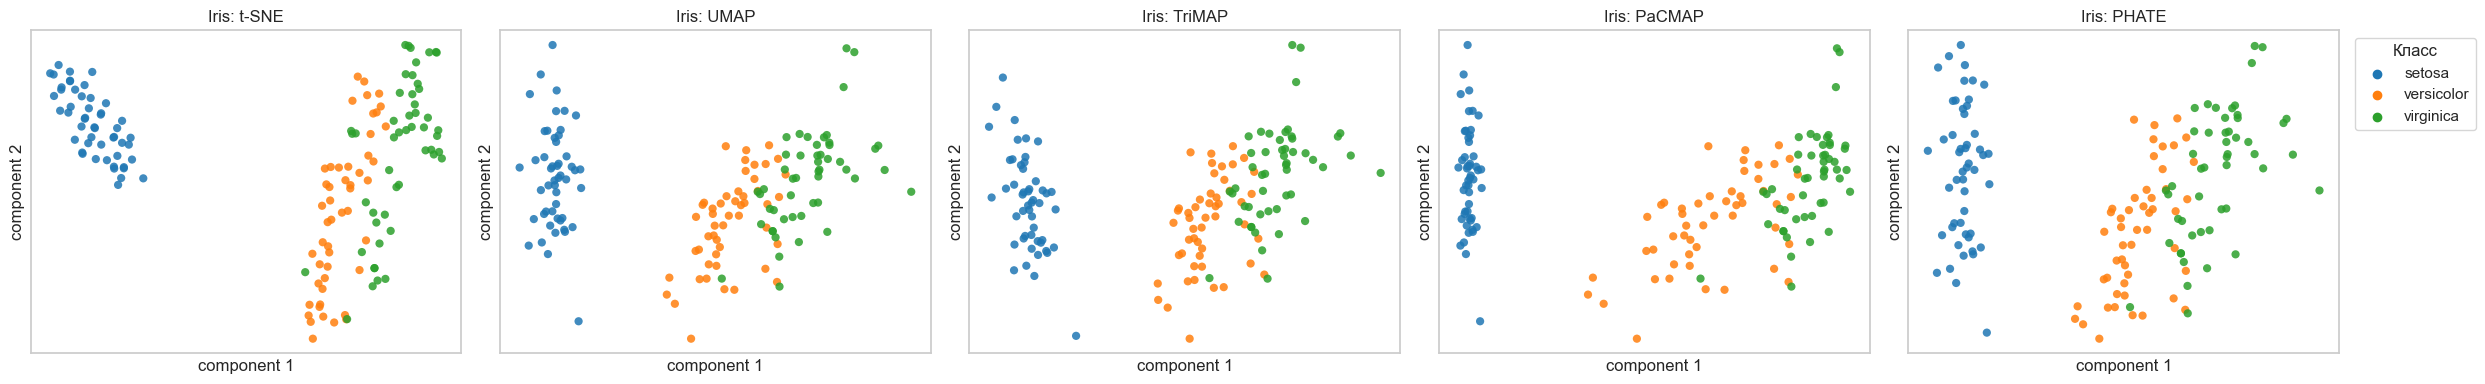

In [10]:
iris_results = []
iris_embeddings = {}
for name, func in METHODS.items():
    emb, row = evaluate_method(name, func, X_iris_scaled, y_iris)
    iris_embeddings[name] = emb
    iris_results.append(row)

iris_results_df = pd.DataFrame(iris_results).sort_values("between/inside", ascending=False)
display(iris_results_df)

fig, axes = plt.subplots(1, len(METHODS), figsize=(5 * len(METHODS), 4))
for ax, (name, emb) in zip(axes, iris_embeddings.items()):
    plot_embedding(emb, y_iris, f"Iris: {name}", class_names_iris, ax=ax, s=35)
    if ax.get_legend() is not None:
        ax.get_legend().remove()
axes[-1].legend(title="Класс", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# 2. Собственный датасет: txhousing

In [12]:
possible_paths = [
    Path("data/txhousing.csv"),
    Path("./txhousing.csv"),
]
for path in possible_paths:
    if path.exists():
        tx_path = path
        break
else:
    raise FileNotFoundError("Не найден txhousing.csv. Поместите файл в папку data рядом с ноутбуком.")

df_tx_raw = pd.read_csv(tx_path)
print("Файл:", tx_path)
print("Размер исходного датасета:", df_tx_raw.shape)
display(df_tx_raw.head())
display(df_tx_raw.describe(include="all").T)

Файл: data\txhousing.csv
Размер исходного датасета: (8602, 10)


,Unnamed: 0,city,year,month,sales,volume,median,listings,inventory,date
0,1,Abilene,2000,1,72.0,5380000.0,71400.0,701.0,6.3,2000.000000
1,2,Abilene,2000,2,98.0,6505000.0,58700.0,746.0,6.6,2000.083333
2,3,Abilene,2000,3,130.0,9285000.0,58100.0,784.0,6.8,2000.166667
3,4,Abilene,2000,4,98.0,9730000.0,68600.0,785.0,6.9,2000.250000
4,5,Abilene,2000,5,141.0,10590000.0,67300.0,794.0,6.8,2000.333333


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,8602.0,NaN,NaN,NaN,4301.5,2483.327841,1.0,2151.25,4301.5,6451.75,8602.0
city,8602,46,Abilene,187,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,8602.0,NaN,NaN,NaN,2007.299465,4.502923,2000.0,2003.0,2007.0,2011.0,2015.0
month,8602.0,NaN,NaN,NaN,6.406417,3.441932,1.0,3.0,6.0,9.0,12.0
sales,8034.0,NaN,NaN,NaN,549.5646,1110.737179,6.0,86.0,169.0,467.0,8945.0
volume,8034.0,NaN,NaN,NaN,106858620.780807,244933668.968117,835000.0,10840000.0,22986824.0,75121388.75,2568156780.0
median,7986.0,NaN,NaN,NaN,128131.442524,37359.575317,50000.0,100000.0,123800.0,150000.0,304200.0
listings,7178.0,NaN,NaN,NaN,3216.90234,5968.331072,0.0,682.0,1283.0,2953.75,43107.0
inventory,7135.0,NaN,NaN,NaN,7.17459,4.612125,0.0,4.9,6.2,8.15,55.9
date,8602.0,NaN,NaN,NaN,2007.75,4.498718,2000.0,2003.833333,2007.75,2011.666667,2015.5


## Подготовка txhousing

`median` используется только для создания целевой переменной `price_segment`, затем удаляется из признаков. Категориальный признак `city` кодируется через OneHotEncoder.

In [14]:
df_tx = df_tx_raw.copy()

required_cols = ["city", "year", "month", "sales", "volume", "median", "listings", "inventory", "date"]
df_tx = df_tx[required_cols].dropna().reset_index(drop=True)

# Три примерно равные группы по медианной цене.
df_tx["price_segment"] = pd.qcut(
    df_tx["median"],
    q=3,
    labels=["low_price", "medium_price", "high_price"],
    duplicates="drop",
)

# Признаки: median удаляем, чтобы не было утечки таргета.
numeric_features = ["year", "month", "sales", "volume", "listings", "inventory", "date"]
categorical_features = ["city"]
target_col = "price_segment"

label_encoder = LabelEncoder()
y_tx = label_encoder.fit_transform(df_tx[target_col].astype(str))
class_names_tx = label_encoder.classes_

ohe = make_ohe()
X_cat = ohe.fit_transform(df_tx[categorical_features])
cat_feature_names = list(ohe.get_feature_names_out(categorical_features))
X_num = df_tx[numeric_features].to_numpy()

X_tx = np.hstack([X_num, X_cat])
feature_names_tx = numeric_features + cat_feature_names

print("Размер после dropna:", df_tx.shape)
print("Матрица признаков:", X_tx.shape)
print("Количество классов:", len(class_names_tx))
print("Классы:", list(class_names_tx))
display(df_tx[target_col].value_counts().reindex(class_names_tx).to_frame("count"))

display(df_tx.head())

Размер после dropna: (7126, 10)
Матрица признаков: (7126, 53)
Количество классов: 3
Классы: ['high_price', 'low_price', 'medium_price']


,count
price_segment,
high_price,2374
low_price,2376
medium_price,2376


,city,year,month,sales,volume,median,listings,inventory,date,price_segment
0,Abilene,2000,1,72.0,5380000.0,71400.0,701.0,6.3,2000.000000,low_price
1,Abilene,2000,2,98.0,6505000.0,58700.0,746.0,6.6,2000.083333,low_price
2,Abilene,2000,3,130.0,9285000.0,58100.0,784.0,6.8,2000.166667,low_price
3,Abilene,2000,4,98.0,9730000.0,68600.0,785.0,6.9,2000.250000,low_price
4,Abilene,2000,5,141.0,10590000.0,67300.0,794.0,6.8,2000.333333,low_price


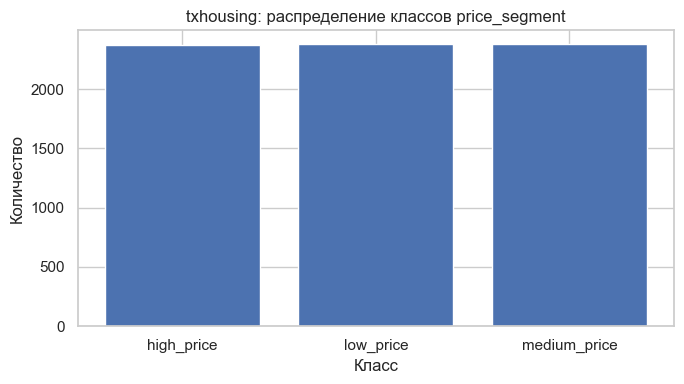

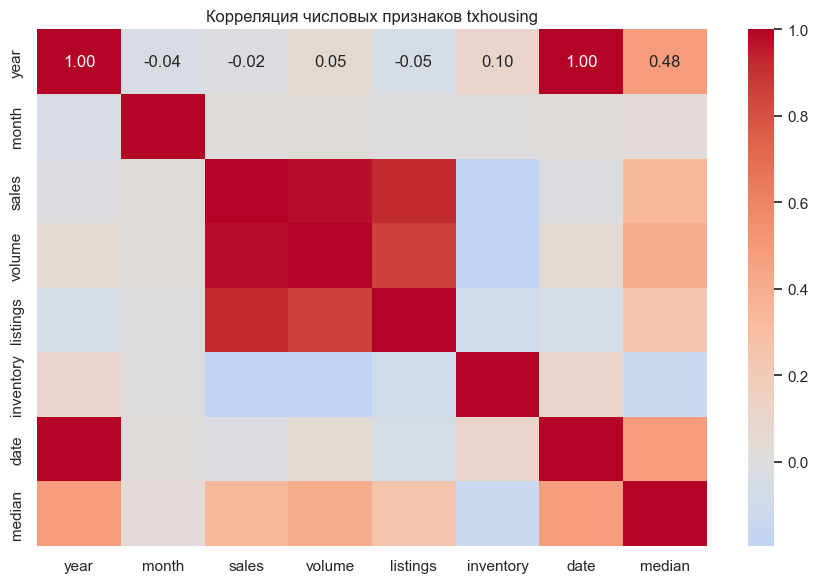

In [15]:
plt.figure(figsize=(7, 4))
counts_for_plot = df_tx["price_segment"].value_counts().reindex(class_names_tx)
plt.bar(counts_for_plot.index.astype(str), counts_for_plot.values)
plt.title("txhousing: распределение классов price_segment")
plt.xlabel("Класс")
plt.ylabel("Количество")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))
sns.heatmap(df_tx[numeric_features + ["median"]].corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Корреляция числовых признаков txhousing")
plt.tight_layout()
plt.show()

## Нормировка и стратифицированная подвыборка

Для тяжёлых нелинейных методов используется стратифицированная подвыборка. Полный датасет остаётся в файле, но графики строятся на подвыборке, чтобы ноутбук запускался стабильно.

In [17]:
scaler_tx = StandardScaler()
X_tx_scaled_full = scaler_tx.fit_transform(X_tx)
X_tx_scaled, y_tx_sample, sample_idx = stratified_sample(X_tx_scaled_full, y_tx, n_samples=SAMPLE_SIZE)
X_tx_raw_sample = X_tx[sample_idx]

print("Полная матрица:", X_tx_scaled_full.shape)
print("Размер подвыборки:", X_tx_scaled.shape)
display(pd.Series(y_tx_sample).value_counts().sort_index().rename(index=dict(enumerate(class_names_tx))).to_frame("count"))

Полная матрица: (7126, 53)
Размер подвыборки: (400, 53)


,count
high_price,133
low_price,134
medium_price,133


# 3. Сравнение t-SNE, UMAP, TriMAP, PaCMAP, PHATE на txhousing

,method,time_sec,inside,between,between/inside
4,PHATE,0.001169,1.666458,1.880621,1.128514
2,TriMAP,0.001105,2.793132,3.100339,1.109987
1,UMAP,0.001588,0.653771,0.725677,1.109987
3,PaCMAP,0.000994,1.538435,1.674412,1.088386
0,t-SNE,0.559473,17.515329,18.134420,1.035346


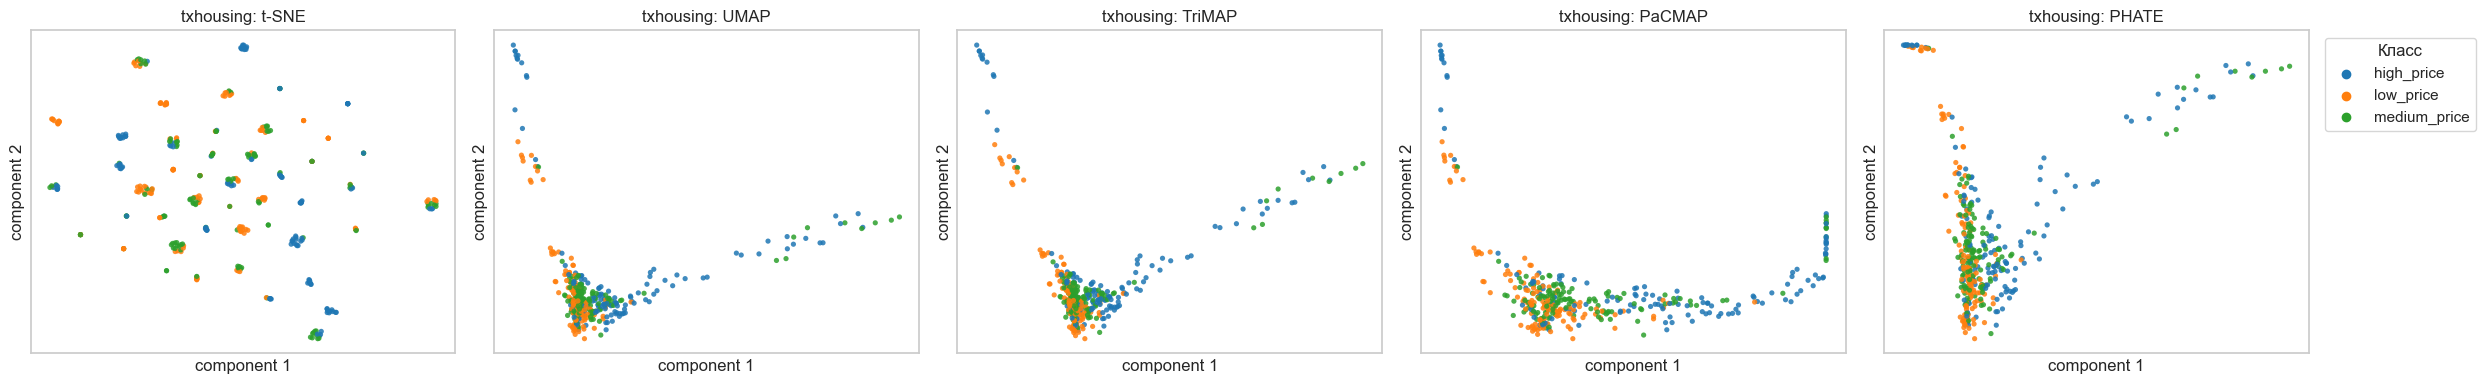

In [19]:
tx_results = []
tx_embeddings = {}
for name, func in METHODS.items():
    emb, row = evaluate_method(name, func, X_tx_scaled, y_tx_sample)
    tx_embeddings[name] = emb
    tx_results.append(row)

tx_results_df = pd.DataFrame(tx_results).sort_values("between/inside", ascending=False)
display(tx_results_df)

fig, axes = plt.subplots(1, len(METHODS), figsize=(5 * len(METHODS), 4))
for ax, (name, emb) in zip(axes, tx_embeddings.items()):
    plot_embedding(emb, y_tx_sample, f"txhousing: {name}", class_names_tx, ax=ax, s=14)
    if ax.get_legend() is not None:
        ax.get_legend().remove()
axes[-1].legend(title="Класс", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Вывод по сравнению методов

Для `txhousing` классы задаются по уровню медианной цены, поэтому они частично отражаются в признаках рынка (`sales`, `volume`, `listings`, `inventory`) и во временных признаках. Нелинейные методы обычно показывают более явные локальные группы, чем простая линейная проекция, однако результат зависит от масштаба признаков и параметров соседства. Поэтому далее проверяется устойчивость к гиперпараметрам.

# 4. Устойчивость t-SNE к `perplexity` и `learning_rate`

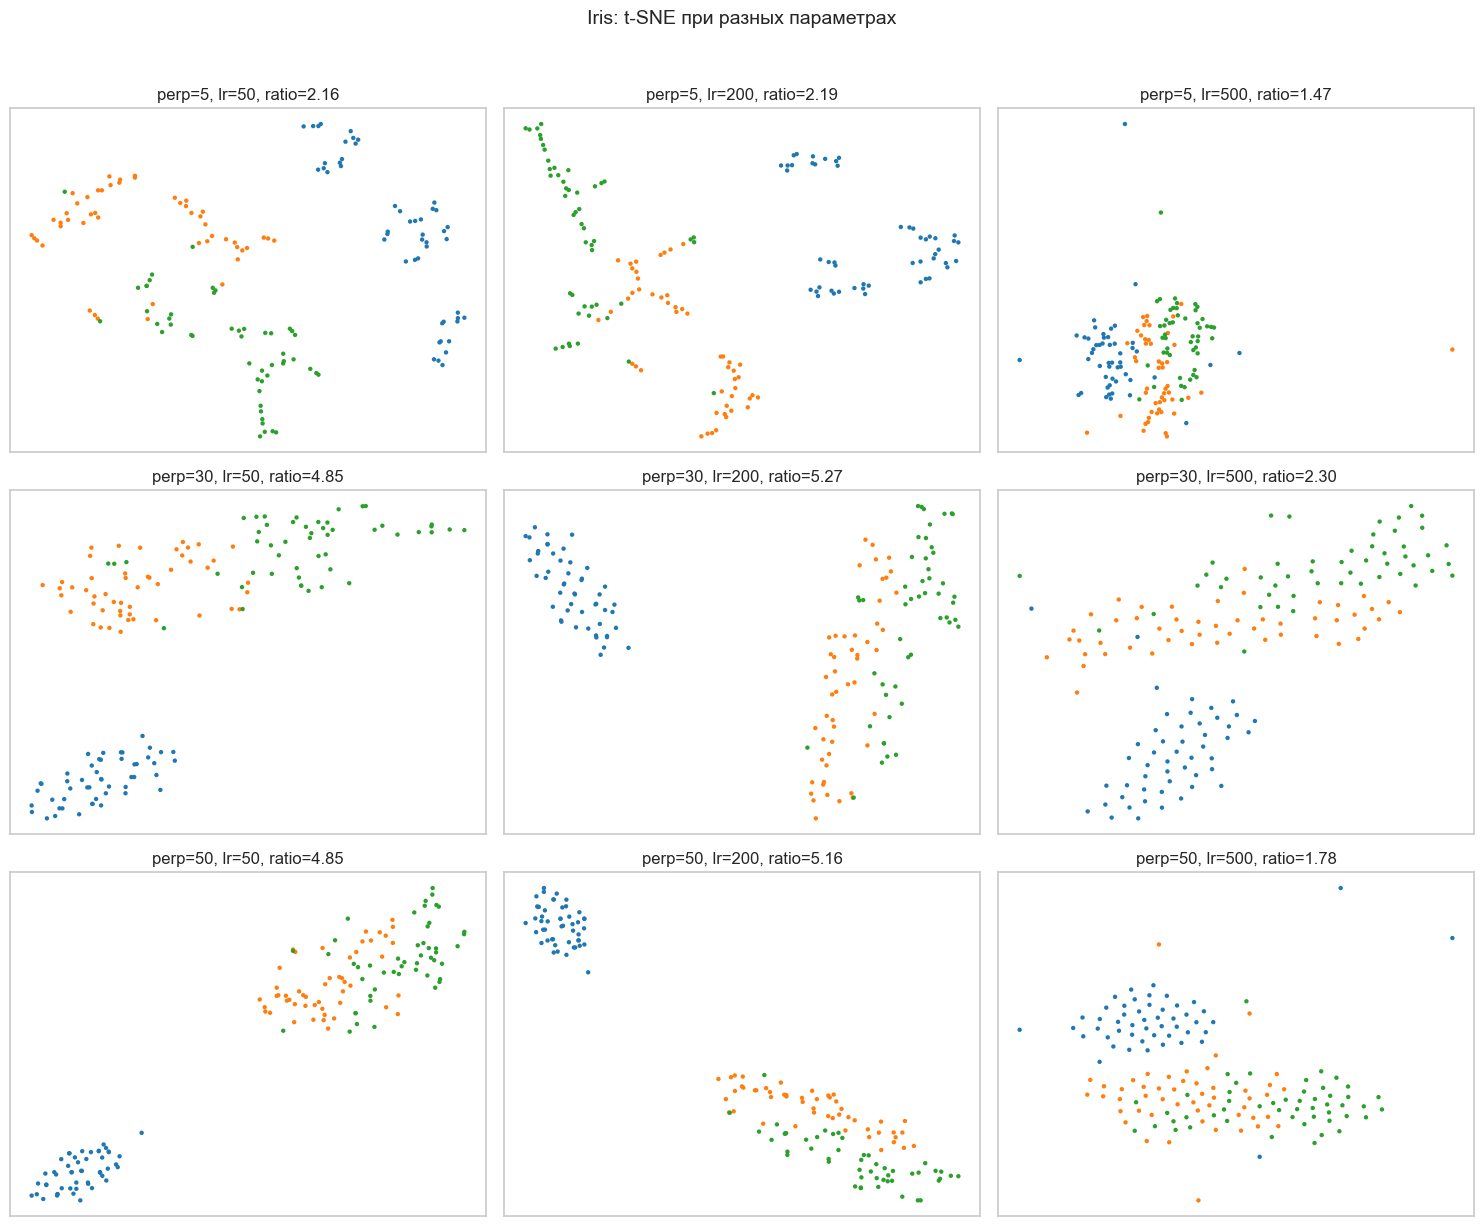

,perplexity,learning_rate,time_sec,inside,between,between/inside
4,30,200,0.159107,3.660258,19.284679,5.268666
7,50,200,0.176578,1.921752,9.909637,5.156563
6,50,50,0.178090,1.930066,9.363201,4.851234
3,30,50,0.162401,3.591650,17.420364,4.850240
5,30,500,0.161749,39.148342,89.881813,2.295929
1,5,200,0.119928,20.639696,45.282993,2.193976
0,5,50,0.118807,15.730154,33.977367,2.160015
8,50,500,0.182757,67.919312,121.191933,1.784352
2,5,500,0.132957,123.120163,180.806656,1.468538


In [22]:
perplexities = [5, 30, 50]
learning_rates = [50, 200, 500]

def plot_tsne_grid(X, y, title_prefix):
    X_grid, y_grid, _ = stratified_sample(X, y, n_samples=GRID_SAMPLE_SIZE, random_state=RANDOM_STATE)
    fig, axes = plt.subplots(len(perplexities), len(learning_rates), figsize=(15, 12))
    rows = []
    for i, perp in enumerate(perplexities):
        for j, lr in enumerate(learning_rates):
            start = time.perf_counter()
            X_emb = run_tsne(X_grid, perplexity=perp, learning_rate=lr)
            elapsed = time.perf_counter() - start
            same, diff, ratio = separation_score(X_emb, y_grid)
            rows.append({"perplexity": perp, "learning_rate": lr, "time_sec": elapsed, "inside": same, "between": diff, "between/inside": ratio})
            ax = axes[i, j]
            sns.scatterplot(x=X_emb[:, 0], y=X_emb[:, 1], hue=y_grid, palette="tab10", s=10, linewidth=0, ax=ax, legend=False)
            ax.set_title(f"perp={perp}, lr={lr}, ratio={ratio:.2f}")
            ax.set_xticks([]); ax.set_yticks([])
    plt.suptitle(title_prefix, y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()
    return pd.DataFrame(rows)

iris_tsne_grid = plot_tsne_grid(X_iris_scaled, y_iris, "Iris: t-SNE при разных параметрах")
display(iris_tsne_grid.sort_values("between/inside", ascending=False))

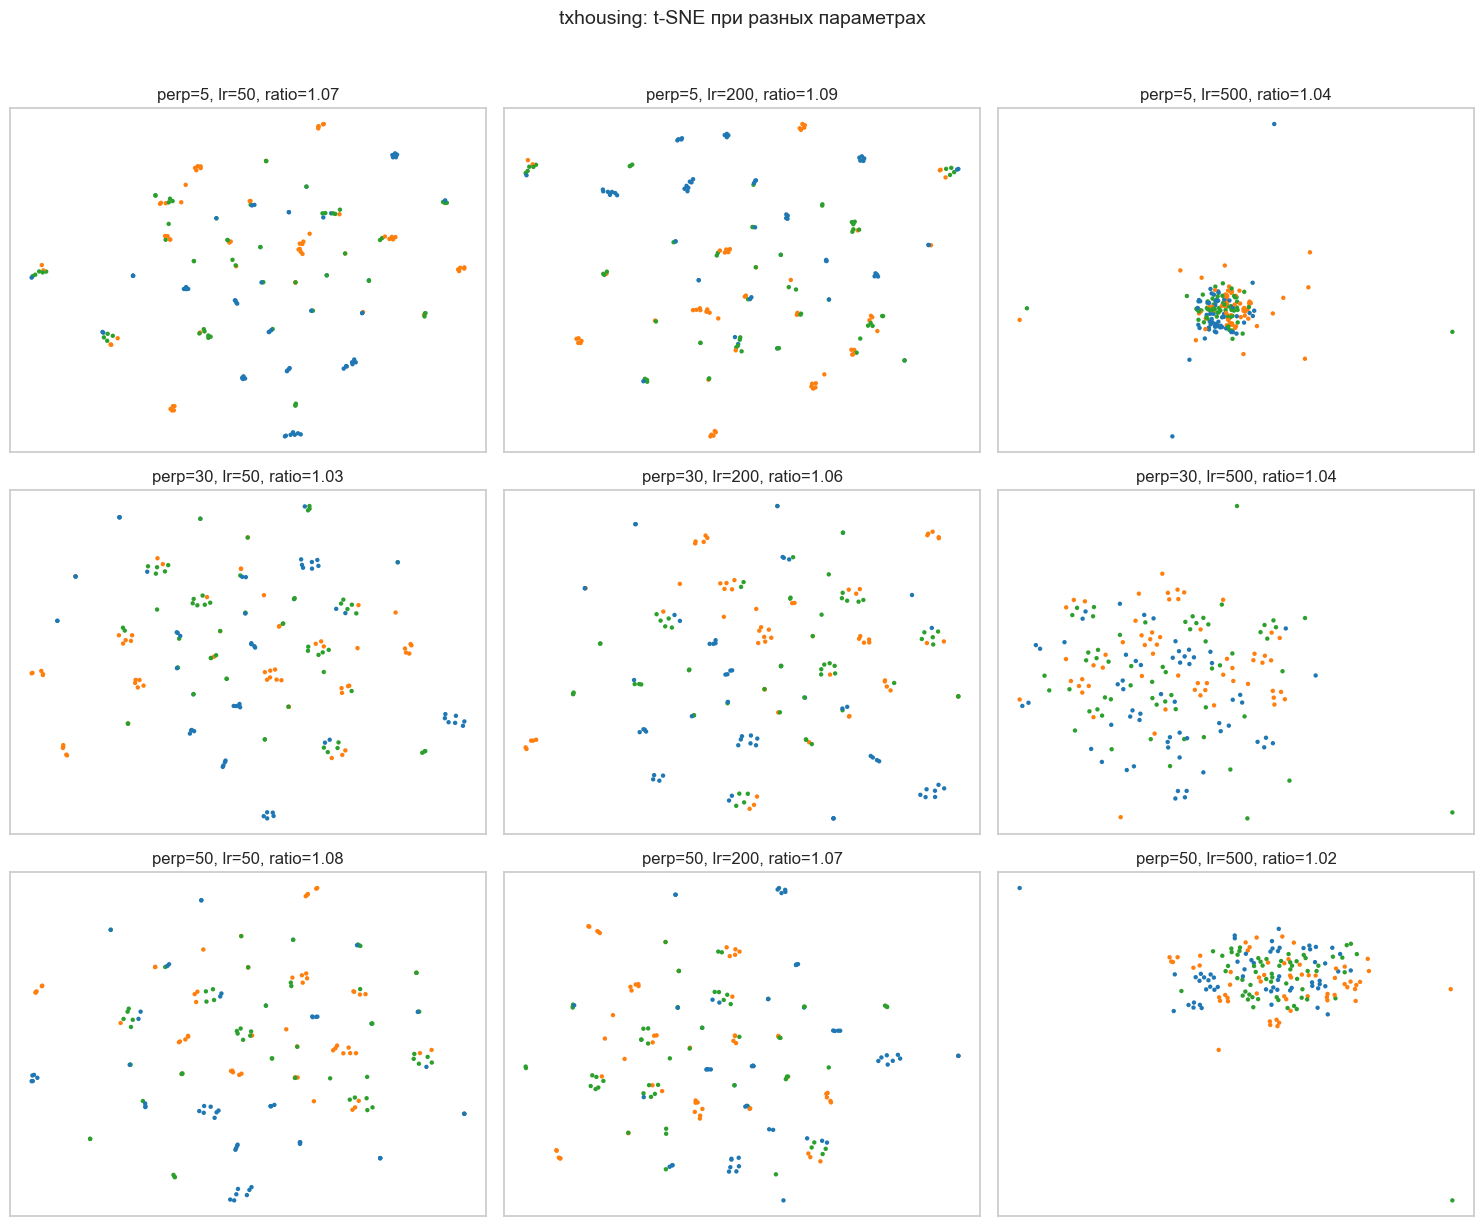

,perplexity,learning_rate,time_sec,inside,between,between/inside
1,5,200,0.163990,32.403431,35.193958,1.086118
6,50,50,0.250292,9.097085,9.810536,1.078426
7,50,200,0.258131,9.272223,9.942203,1.072257
0,5,50,0.150329,28.874609,30.759407,1.065275
4,30,200,0.215542,11.995483,12.759093,1.063658
2,5,500,0.174058,216.263306,225.753357,1.043882
5,30,500,0.246779,67.533058,70.346207,1.041656
3,30,50,0.217884,12.164321,12.507390,1.028203
8,50,500,0.270121,67.747910,69.145386,1.020628


In [23]:
tx_tsne_grid = plot_tsne_grid(X_tx_scaled, y_tx_sample, "txhousing: t-SNE при разных параметрах")
display(tx_tsne_grid.sort_values("between/inside", ascending=False))

### Вывод по t-SNE

При малом `perplexity` метод сильнее дробит данные на маленькие локальные группы. При `perplexity=30–50` структура обычно становится стабильнее. `learning_rate` влияет на масштаб и форму облаков: слишком маленькое значение может давать плотные сжатые группы, слишком большое — растянутые и менее интерпретируемые структуры.

# 5. Устойчивость UMAP к `n_neighbors` и `min_dist`

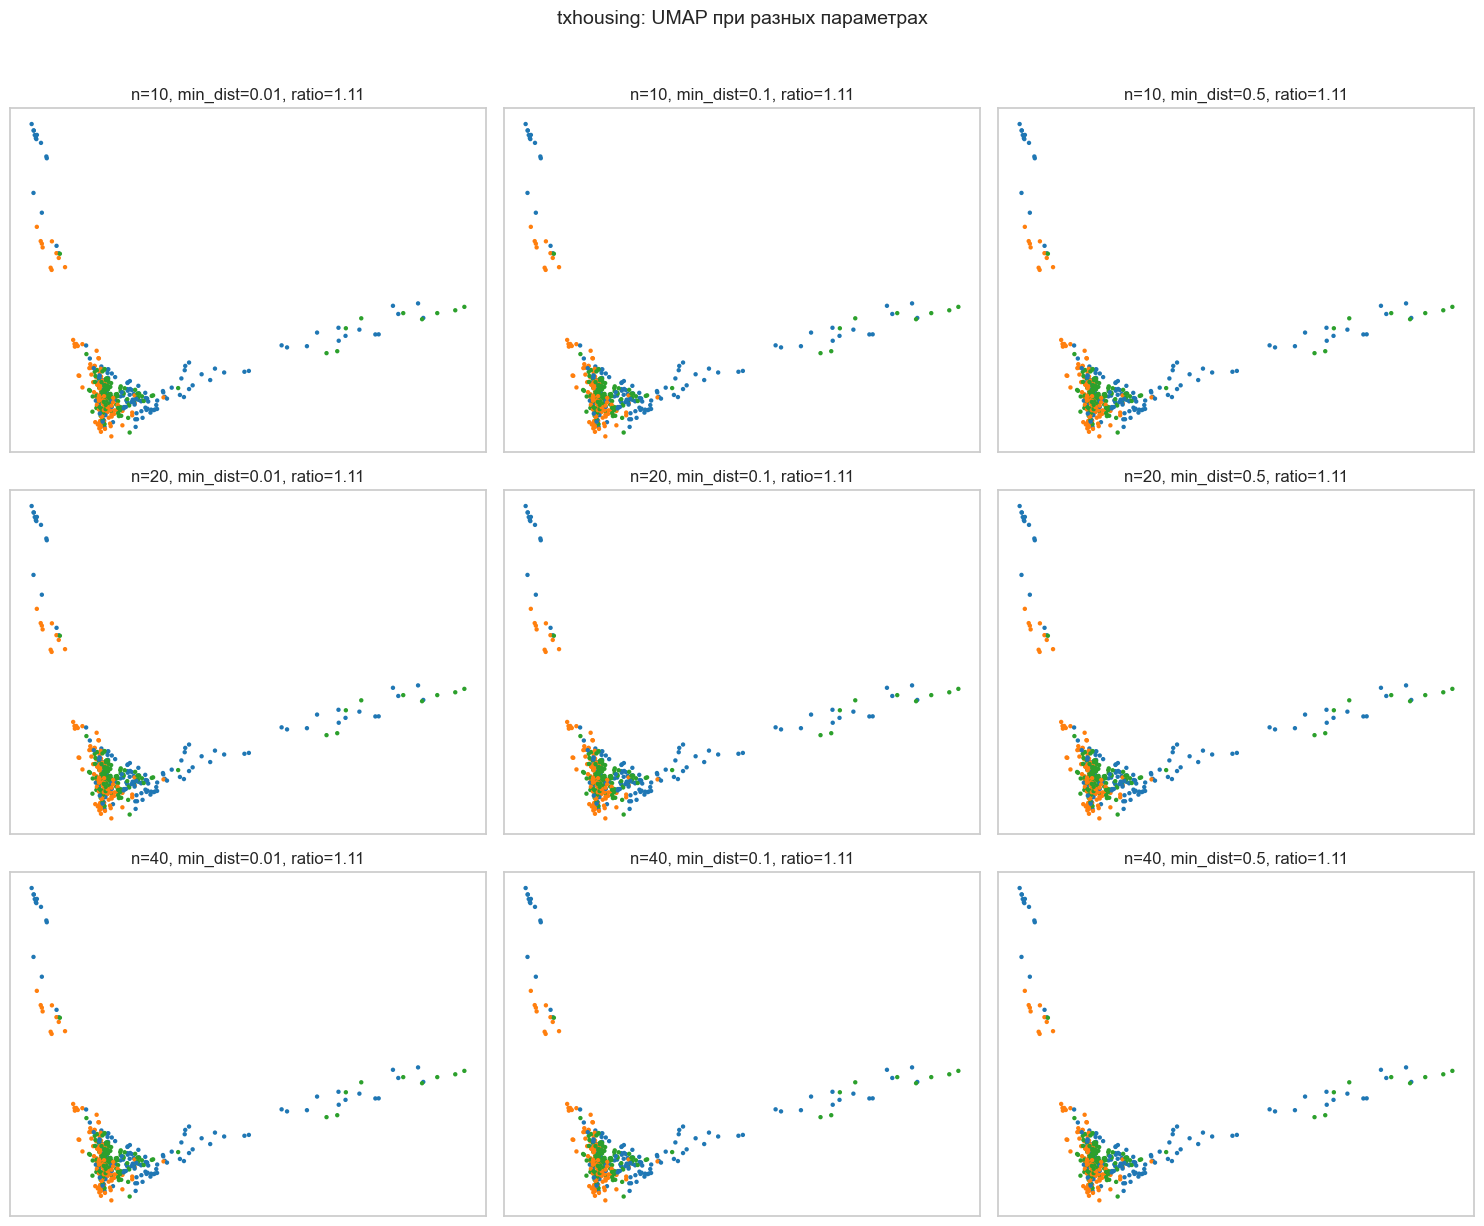

,n_neighbors,min_dist,time_sec,inside,between,between/inside
0,10,0.01,0.001307,0.735191,0.816052,1.109987
3,20,0.01,0.001158,0.519858,0.577036,1.109987
4,20,0.10,0.001166,0.566182,0.628455,1.109987
5,20,0.50,0.001218,0.772067,0.856984,1.109987
6,40,0.01,0.001167,0.367595,0.408026,1.109987
2,10,0.50,0.001187,1.091867,1.211958,1.109987
8,40,0.50,0.001189,0.545934,0.605979,1.109987
1,10,0.10,0.001266,0.800703,0.888769,1.109987
7,40,0.10,0.001174,0.400351,0.444385,1.109987


In [26]:
n_neighbors_list = [10, 20, 40]
min_dists = [0.01, 0.1, 0.5]

fig, axes = plt.subplots(len(n_neighbors_list), len(min_dists), figsize=(15, 12))
umap_grid_rows = []
for i, n_neighbors in enumerate(n_neighbors_list):
    for j, min_dist in enumerate(min_dists):
        start = time.perf_counter()
        X_emb = run_umap(X_tx_scaled, n_neighbors=n_neighbors, min_dist=min_dist)
        elapsed = time.perf_counter() - start
        same, diff, ratio = separation_score(X_emb, y_tx_sample)
        umap_grid_rows.append({"n_neighbors": n_neighbors, "min_dist": min_dist, "time_sec": elapsed, "inside": same, "between": diff, "between/inside": ratio})
        ax = axes[i, j]
        sns.scatterplot(x=X_emb[:, 0], y=X_emb[:, 1], hue=y_tx_sample, palette="tab10", s=10, linewidth=0, ax=ax, legend=False)
        ax.set_title(f"n={n_neighbors}, min_dist={min_dist}, ratio={ratio:.2f}")
        ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("txhousing: UMAP при разных параметрах", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

umap_grid_df = pd.DataFrame(umap_grid_rows).sort_values("between/inside", ascending=False)
display(umap_grid_df)

### Вывод по UMAP

`n_neighbors` управляет балансом локальной и глобальной структуры. Малые значения сильнее выделяют локальные группы, большие сглаживают общую картину. `min_dist` задаёт плотность кластеров: при маленьком значении кластеры компактнее, при большом — более растянуты.

# 6. Дополнительные строки графиков для TriMAP, PaCMAP, PHATE

Задание: для каждого метода построить по одной строке графиков с варьированием ключевого параметра и оценить устойчивость рисунка.

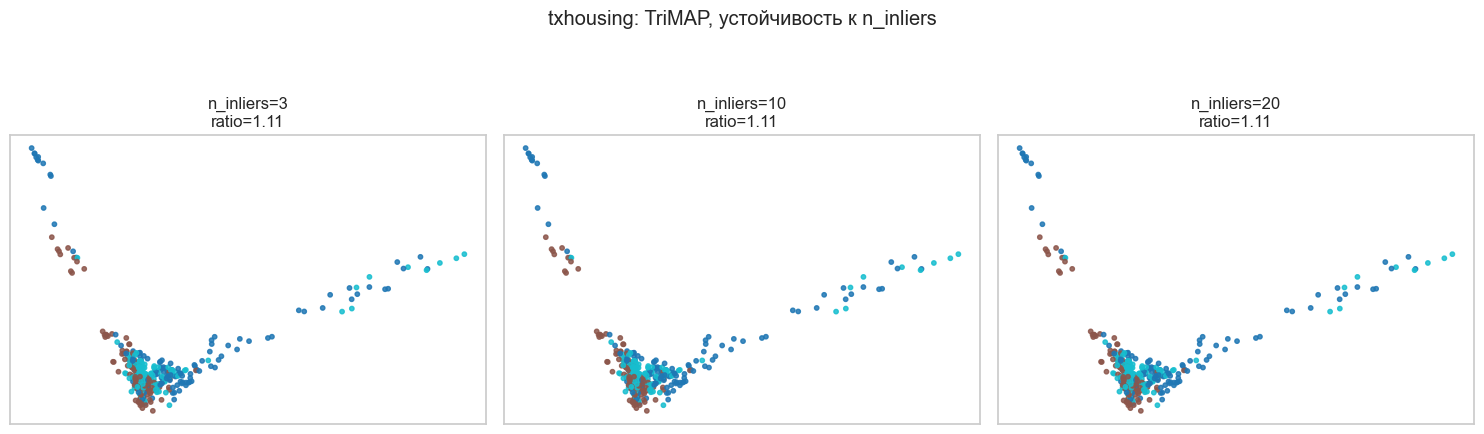

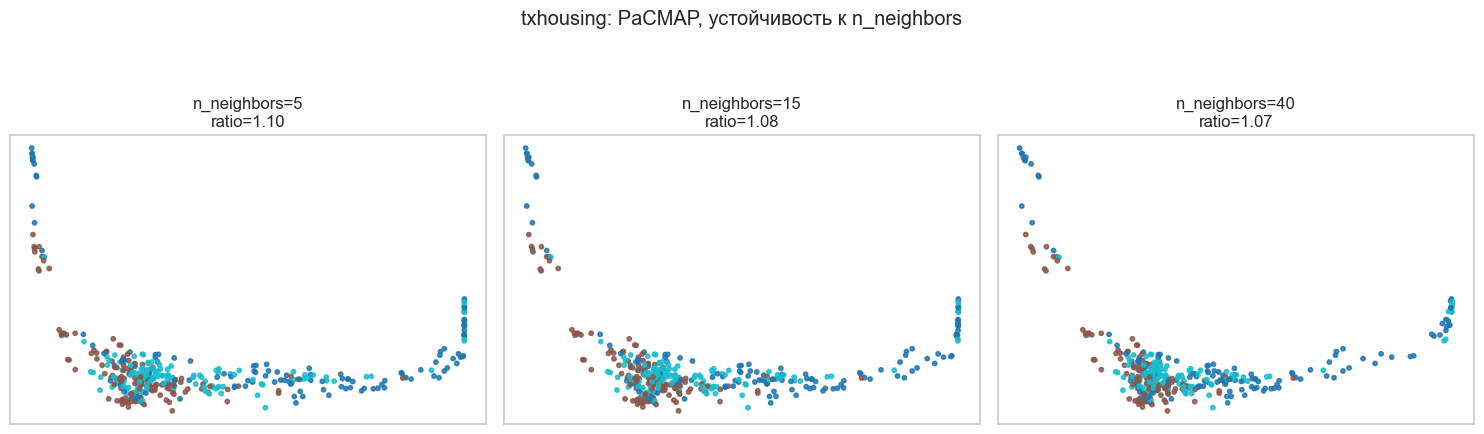

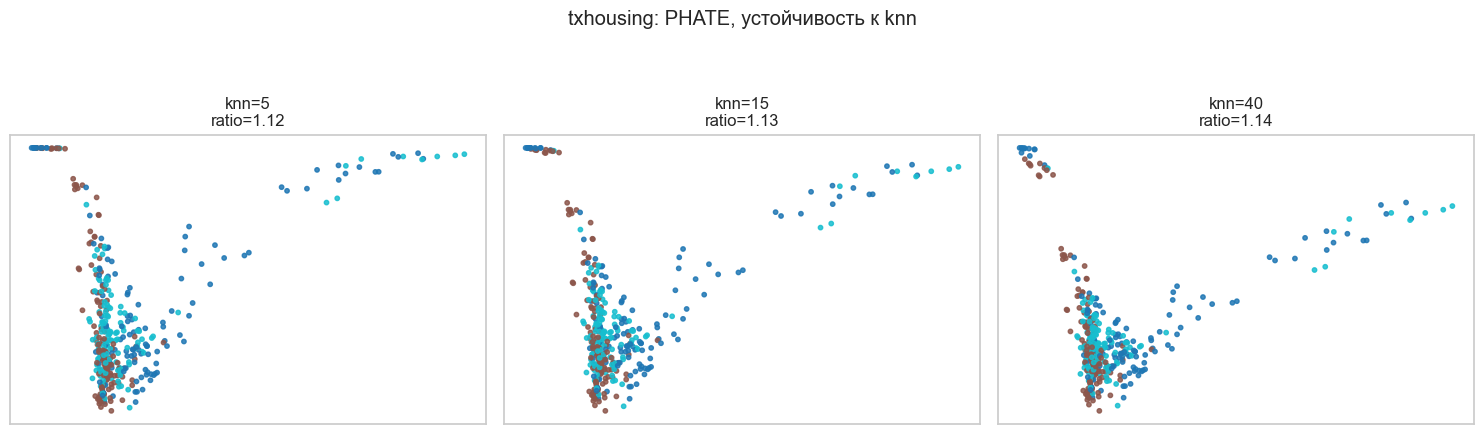

,method,n_inliers,time_sec,inside,between,between/inside,n_neighbors,knn
0,TriMAP,3.0,0.001406,2.467267,2.738633,1.109987,NaN,NaN
1,TriMAP,10.0,0.001203,2.793132,3.100339,1.109987,NaN,NaN
2,TriMAP,20.0,0.001003,3.258654,3.617062,1.109987,NaN,NaN
3,PaCMAP,NaN,0.002325,1.562913,1.711744,1.095227,5.0,NaN
4,PaCMAP,NaN,0.001169,1.519260,1.645275,1.082946,15.0,NaN
5,PaCMAP,NaN,0.001233,1.465579,1.564213,1.067301,40.0,NaN
6,PHATE,NaN,0.001928,1.718021,1.929942,1.123352,NaN,5.0
7,PHATE,NaN,0.001231,1.666458,1.880621,1.128514,NaN,15.0
8,PHATE,NaN,0.001109,1.599947,1.817904,1.136228,NaN,40.0


In [29]:
def one_row_grid(method_name, param_name, values, run_func):
    fig, axes = plt.subplots(1, len(values), figsize=(5 * len(values), 4))
    rows = []
    for ax, value in zip(axes, values):
        start = time.perf_counter()
        X_emb = run_func(value)
        elapsed = time.perf_counter() - start
        same, diff, ratio = separation_score(X_emb, y_tx_sample)
        rows.append({"method": method_name, param_name: value, "time_sec": elapsed, "inside": same, "between": diff, "between/inside": ratio})
        ax.scatter(X_emb[:, 0], X_emb[:, 1], c=y_tx_sample, cmap="tab10", s=10, alpha=0.85)
        ax.set_title(f"{param_name}={value}\nratio={ratio:.2f}")
        ax.set_xticks([]); ax.set_yticks([])
    plt.suptitle(f"txhousing: {method_name}, устойчивость к {param_name}", y=1.08)
    plt.tight_layout()
    plt.show()
    return pd.DataFrame(rows)

trimap_stability = one_row_grid(
    "TriMAP", "n_inliers", [3, 10, 20],
    lambda v: run_trimap(X_tx_scaled, n_inliers=v, n_outliers=5),
)
pacmap_stability = one_row_grid(
    "PaCMAP", "n_neighbors", [5, 15, 40],
    lambda v: run_pacmap(X_tx_scaled, n_neighbors=v),
)
phate_stability = one_row_grid(
    "PHATE", "knn", [5, 15, 40],
    lambda v: run_phate(X_tx_scaled, knn=v),
)

stability_df = pd.concat([trimap_stability, pacmap_stability, phate_stability], ignore_index=True)
display(stability_df)

### Вывод по устойчивости TriMAP, PaCMAP, PHATE

- **TriMAP** при малом числе `n_inliers` сильнее подчёркивает локальные связи; при увеличении параметра группы становятся более сглаженными.
- **PaCMAP** заметно зависит от `n_neighbors`: малое значение делает разбиение более детальным, большое — сглаживает структуру.
- **PHATE** через `knn` управляет диффузионной связностью: малые значения могут давать более фрагментированную картину, большие — более непрерывную.

# 7. Итоговая таблица сравнения методов

In [32]:
method_summary = pd.DataFrame({
    "Метод": ["t-SNE", "UMAP", "TriMAP", "PaCMAP", "PHATE"],
    "Скорость на больших данных": ["Низкая", "Высокая/средняя", "Средняя", "Средняя", "Средняя/низкая"],
    "Локальное разделение": ["Очень хорошее", "Очень хорошее", "Хорошее", "Очень хорошее", "Хорошее"],
    "Глобальная структура": ["Слабее", "Средняя/хорошая", "Хорошая", "Хорошая", "Хорошая для траекторий"],
    "Чувствительность к параметрам": ["Высокая", "Средняя", "Средняя", "Средняя", "Средняя"],
    "Ключевые параметры": ["perplexity, learning_rate", "n_neighbors, min_dist", "n_inliers, n_outliers", "n_neighbors", "knn"],
})
display(method_summary)

,Метод,Скорость на больших данных,Локальное разделение,Глобальная структура,Чувствительность к параметрам,Ключевые параметры
0,t-SNE,Низкая,Очень хорошее,Слабее,Высокая,"perplexity, learning_rate"
1,UMAP,Высокая/средняя,Очень хорошее,Средняя/хорошая,Средняя,"n_neighbors, min_dist"
2,TriMAP,Средняя,Хорошее,Хорошая,Средняя,"n_inliers, n_outliers"
3,PaCMAP,Средняя,Очень хорошее,Хорошая,Средняя,n_neighbors
4,PHATE,Средняя/низкая,Хорошее,Хорошая для траекторий,Средняя,knn


# 8. Варианты препроцессинга

Задание: явно сравнить, как UMAP и t-SNE реагируют на разные варианты нормировки и отбора признаков.

Сценарии:

1. **Raw** — без масштабирования.
2. **StandardScaler** — z-нормировка.
3. **MinMaxScaler + VarianceThreshold** — нормировка в диапазон `[0, 1]` и удаление признаков с низкой дисперсией.

In [34]:
X_raw_full = X_tx.copy()
X_standard_full = StandardScaler().fit_transform(X_tx)

minmax = MinMaxScaler()
X_minmax_full = minmax.fit_transform(X_tx)
selector = VarianceThreshold(threshold=0.01)
X_minmax_selected_full = selector.fit_transform(X_minmax_full)
selected_mask = selector.get_support()
selected_features = [name for name, keep in zip(feature_names_tx, selected_mask) if keep]
dropped_features = [name for name, keep in zip(feature_names_tx, selected_mask) if not keep]

# Используем те же индексы подвыборки, чтобы сравнение было честным.
preprocessing_scenarios = {
    "Raw": X_raw_full[sample_idx],
    "StandardScaler": X_standard_full[sample_idx],
    "MinMax + VarianceThreshold": X_minmax_selected_full[sample_idx],
}

print("Исходное число признаков:", X_tx.shape[1])
print("После MinMax + VarianceThreshold:", X_minmax_selected_full.shape[1])
print("Отброшено признаков:", len(dropped_features))
display(pd.DataFrame({"dropped_feature": dropped_features}).head(30))

Исходное число признаков: 53
После MinMax + VarianceThreshold: 51
Отброшено признаков: 2


,dropped_feature
0,inventory
1,city_South Padre Island


## 8.1. t-SNE при разных сценариях препроцессинга

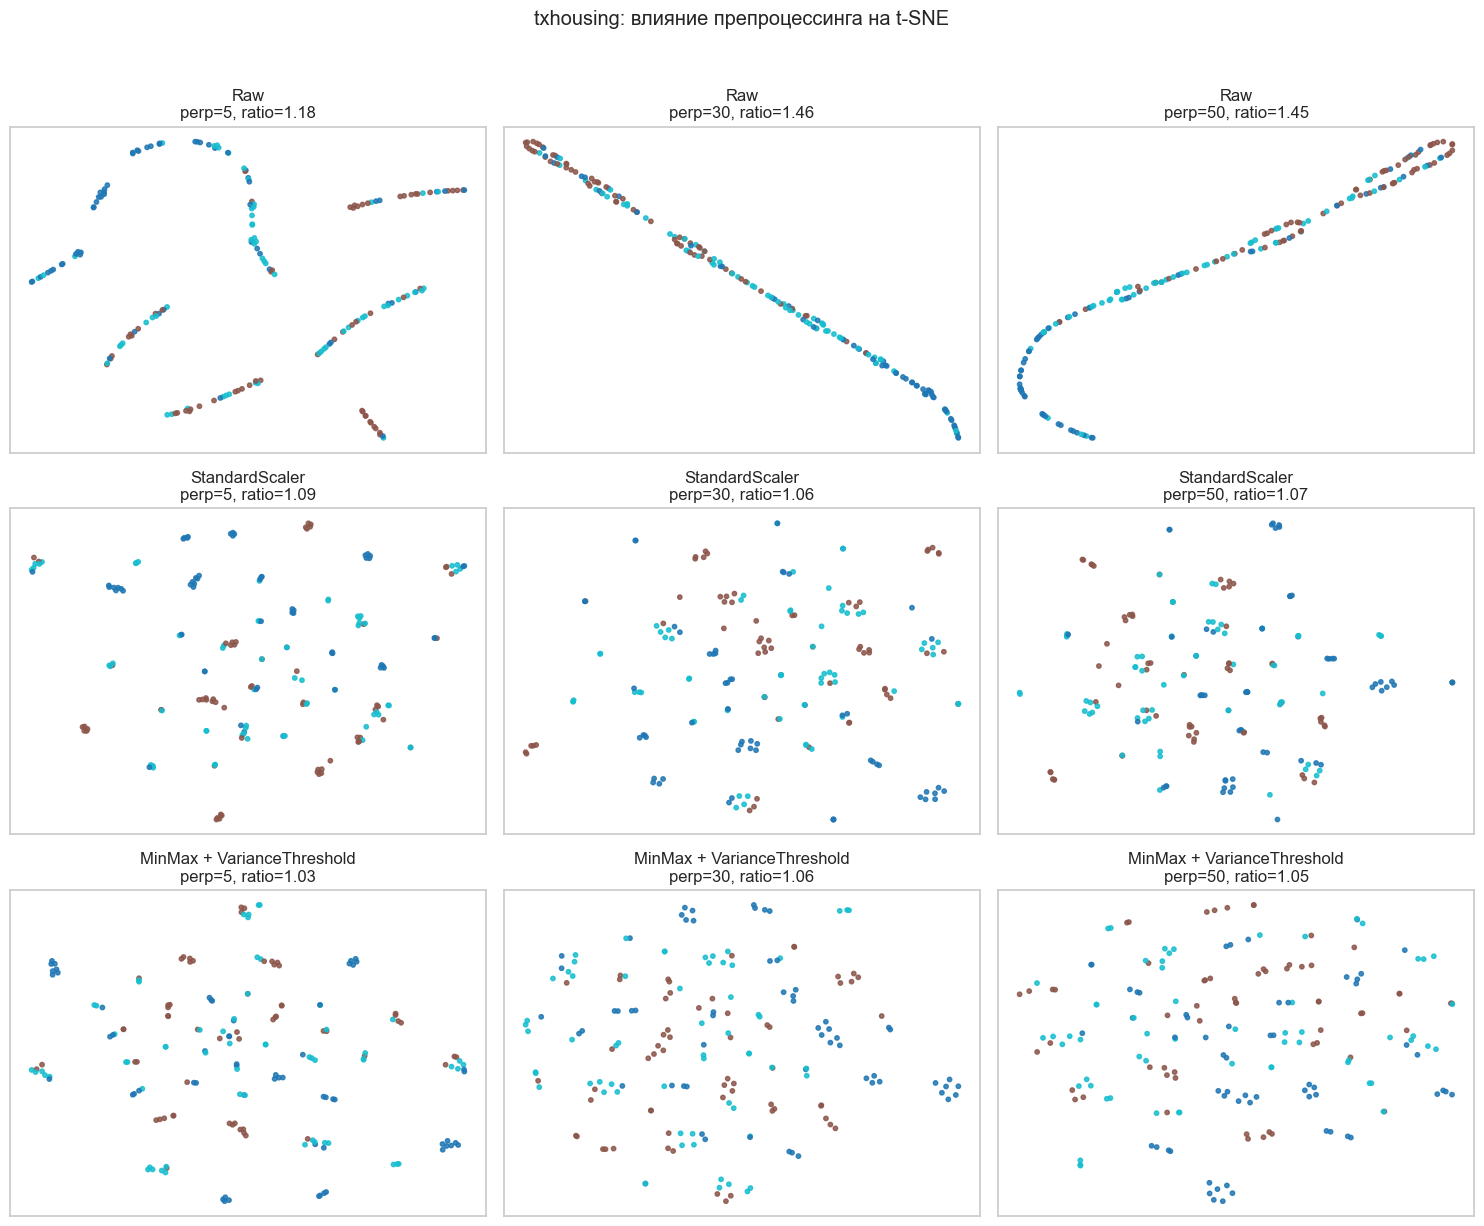

,method,scenario,perplexity,time_sec,inside,between,between/inside
1,t-SNE,Raw,30,0.203596,9.764174,14.249942,1.459411
2,t-SNE,Raw,50,0.242770,5.273154,7.662951,1.453201
0,t-SNE,Raw,5,0.139823,34.166374,40.176979,1.175922
3,t-SNE,StandardScaler,5,0.163190,32.403431,35.193958,1.086118
5,t-SNE,StandardScaler,50,0.241554,9.272223,9.942203,1.072257
4,t-SNE,StandardScaler,30,0.214475,11.995483,12.759093,1.063658
7,t-SNE,MinMax + VarianceThreshold,30,0.216456,14.112568,14.997057,1.062674
8,t-SNE,MinMax + VarianceThreshold,50,0.238705,10.224118,10.720730,1.048573
6,t-SNE,MinMax + VarianceThreshold,5,0.162593,32.376614,33.200932,1.025460


In [36]:
prep_tsne_rows = []
fig, axes = plt.subplots(len(preprocessing_scenarios), 3, figsize=(15, 4 * len(preprocessing_scenarios)))
perplexity_for_prep = [5, 30, 50]

for i, (scenario_name, X_scenario) in enumerate(preprocessing_scenarios.items()):
    X_scenario_small, y_scenario_small, _ = stratified_sample(X_scenario, y_tx_sample, n_samples=GRID_SAMPLE_SIZE, random_state=RANDOM_STATE)
    for j, perp in enumerate(perplexity_for_prep):
        start = time.perf_counter()
        X_emb = run_tsne(X_scenario_small, perplexity=perp, learning_rate=200)
        elapsed = time.perf_counter() - start
        same, diff, ratio = separation_score(X_emb, y_scenario_small)
        prep_tsne_rows.append({"method": "t-SNE", "scenario": scenario_name, "perplexity": perp, "time_sec": elapsed, "inside": same, "between": diff, "between/inside": ratio})
        ax = axes[i, j]
        ax.scatter(X_emb[:, 0], X_emb[:, 1], c=y_scenario_small, cmap="tab10", s=10, alpha=0.85)
        ax.set_title(f"{scenario_name}\nperp={perp}, ratio={ratio:.2f}")
        ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("txhousing: влияние препроцессинга на t-SNE", y=1.02)
plt.tight_layout()
plt.show()

prep_tsne_df = pd.DataFrame(prep_tsne_rows).sort_values("between/inside", ascending=False)
display(prep_tsne_df)

## 8.2. UMAP при разных сценариях препроцессинга

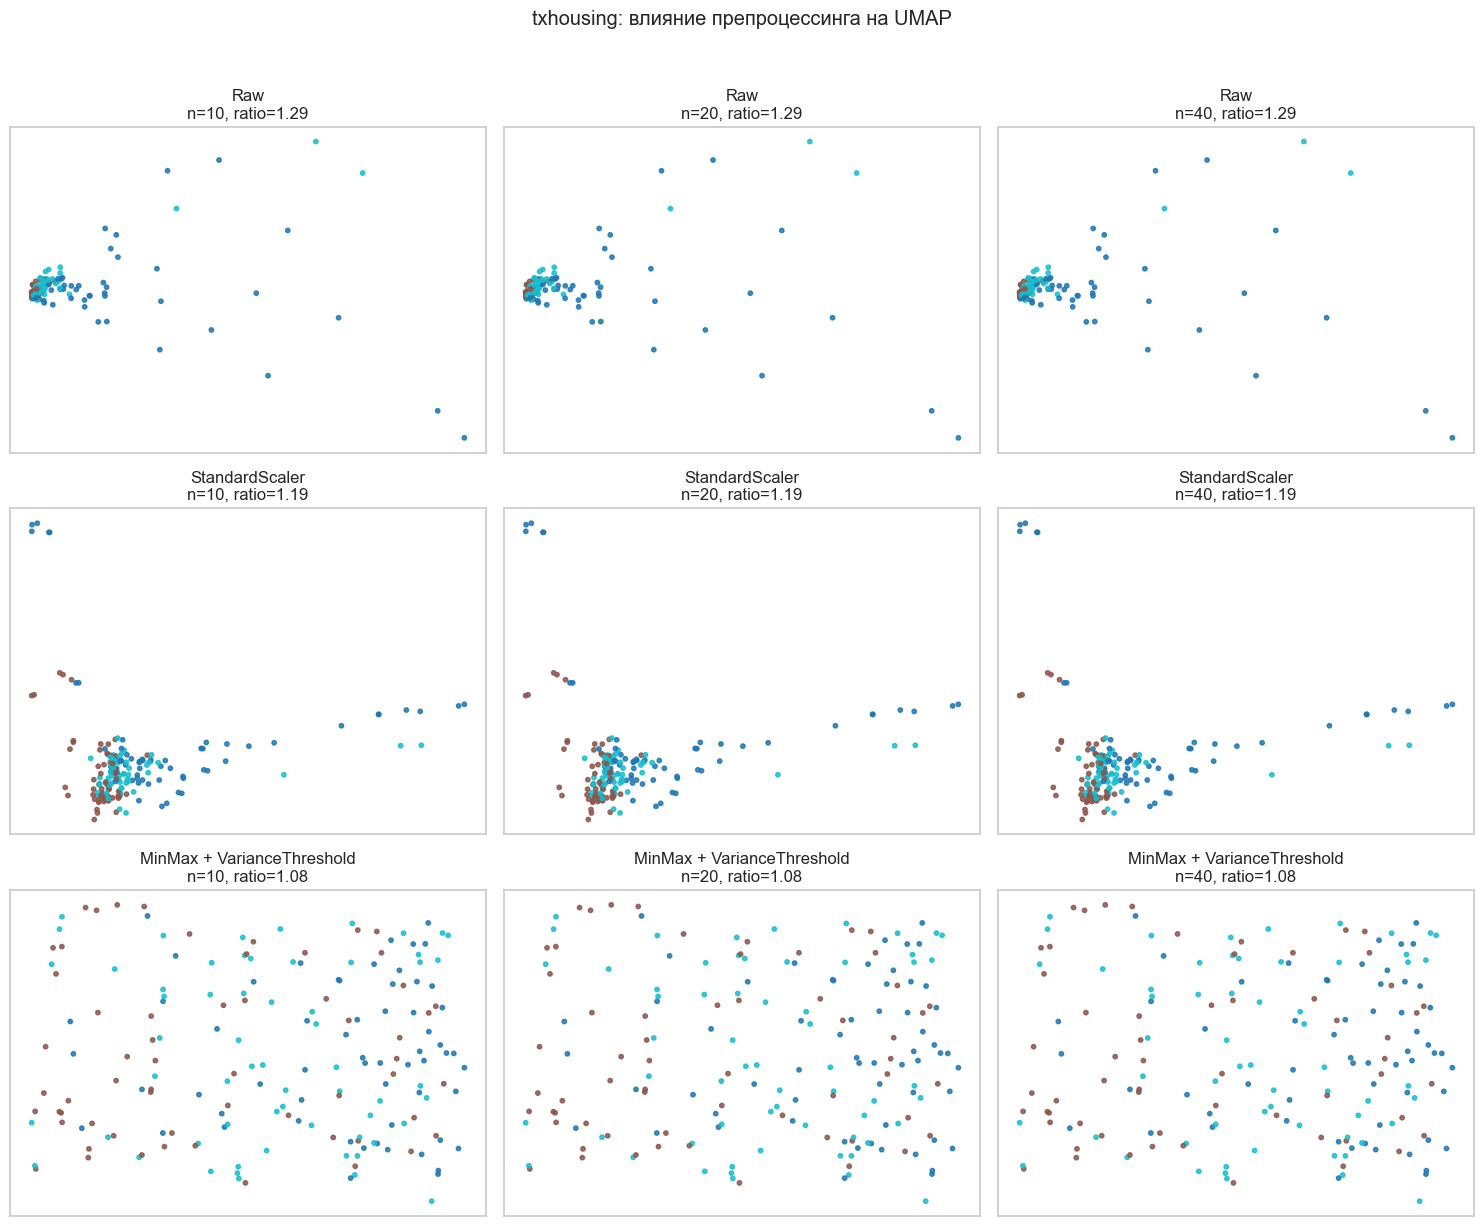

,method,scenario,n_neighbors,min_dist,time_sec,inside,between,between/inside
0,UMAP,Raw,10,0.1,0.000891,5.678835e+07,7.329516e+07,1.290673
2,UMAP,Raw,40,0.1,0.000744,2.839417e+07,3.664758e+07,1.290673
1,UMAP,Raw,20,0.1,0.000757,4.015542e+07,5.182750e+07,1.290673
3,UMAP,StandardScaler,10,0.1,0.000778,8.062411e-01,9.603145e-01,1.191101
4,UMAP,StandardScaler,20,0.1,0.000791,5.700986e-01,6.790449e-01,1.191101
5,UMAP,StandardScaler,40,0.1,0.000811,4.031206e-01,4.801573e-01,1.191101
7,UMAP,MinMax + VarianceThreshold,20,0.1,0.000771,1.621958e-01,1.756730e-01,1.083092
6,UMAP,MinMax + VarianceThreshold,10,0.1,0.000771,2.293796e-01,2.484392e-01,1.083092
8,UMAP,MinMax + VarianceThreshold,40,0.1,0.000769,1.146898e-01,1.242196e-01,1.083092


In [38]:
prep_umap_rows = []
fig, axes = plt.subplots(len(preprocessing_scenarios), 3, figsize=(15, 4 * len(preprocessing_scenarios)))
neighbors_for_prep = [10, 20, 40]

for i, (scenario_name, X_scenario) in enumerate(preprocessing_scenarios.items()):
    X_scenario_small, y_scenario_small, _ = stratified_sample(X_scenario, y_tx_sample, n_samples=GRID_SAMPLE_SIZE, random_state=RANDOM_STATE)
    for j, n_neighbors in enumerate(neighbors_for_prep):
        start = time.perf_counter()
        X_emb = run_umap(X_scenario_small, n_neighbors=n_neighbors, min_dist=0.1)
        elapsed = time.perf_counter() - start
        same, diff, ratio = separation_score(X_emb, y_scenario_small)
        prep_umap_rows.append({"method": "UMAP", "scenario": scenario_name, "n_neighbors": n_neighbors, "min_dist": 0.1, "time_sec": elapsed, "inside": same, "between": diff, "between/inside": ratio})
        ax = axes[i, j]
        ax.scatter(X_emb[:, 0], X_emb[:, 1], c=y_scenario_small, cmap="tab10", s=10, alpha=0.85)
        ax.set_title(f"{scenario_name}\nn={n_neighbors}, ratio={ratio:.2f}")
        ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("txhousing: влияние препроцессинга на UMAP", y=1.02)
plt.tight_layout()
plt.show()

prep_umap_df = pd.DataFrame(prep_umap_rows).sort_values("between/inside", ascending=False)
display(prep_umap_df)

## 8.3. Сводная таблица по препроцессингу и времени

In [40]:
prep_summary = pd.concat([prep_tsne_df, prep_umap_df], ignore_index=True, sort=False)
summary_cols = ["method", "scenario", "perplexity", "n_neighbors", "min_dist", "time_sec", "between/inside"]
display(prep_summary[summary_cols].sort_values(["method", "between/inside"], ascending=[True, False]))

runtime_summary = prep_summary.groupby(["method", "scenario"], as_index=False)["time_sec"].mean()
display(runtime_summary.sort_values(["method", "time_sec"]))

,method,scenario,perplexity,n_neighbors,min_dist,time_sec,between/inside
9,UMAP,Raw,NaN,10.0,0.1,0.000891,1.290673
10,UMAP,Raw,NaN,40.0,0.1,0.000744,1.290673
11,UMAP,Raw,NaN,20.0,0.1,0.000757,1.290673
12,UMAP,StandardScaler,NaN,10.0,0.1,0.000778,1.191101
13,UMAP,StandardScaler,NaN,20.0,0.1,0.000791,1.191101
14,UMAP,StandardScaler,NaN,40.0,0.1,0.000811,1.191101
15,UMAP,MinMax + VarianceThreshold,NaN,20.0,0.1,0.000771,1.083092
16,UMAP,MinMax + VarianceThreshold,NaN,10.0,0.1,0.000771,1.083092
17,UMAP,MinMax + VarianceThreshold,NaN,40.0,0.1,0.000769,1.083092
0,t-SNE,Raw,30.0,NaN,NaN,0.203596,1.459411


,method,scenario,time_sec
0,UMAP,MinMax + VarianceThreshold,0.000770
2,UMAP,StandardScaler,0.000793
1,UMAP,Raw,0.000797
4,t-SNE,Raw,0.195396
3,t-SNE,MinMax + VarianceThreshold,0.205918
5,t-SNE,StandardScaler,0.206406


# Ответы на задания по препроцессингу

## 1. Какие признаки были отброшены и почему это влияет на кластеризацию

`VarianceThreshold` удаляет признаки, у которых после `MinMaxScaler` слишком маленькая дисперсия. В этом датасете чаще всего удаляются редкие one-hot признаки городов: если город встречается редко, соответствующий бинарный столбец почти всегда равен нулю. Такие признаки могут добавлять шум в расстояния между объектами, но почти не помогают выделять общую структуру рынка жилья. Удаление низкодисперсионных признаков уменьшает размерность и может сделать t-SNE/UMAP устойчивее.

## 2. Сравнение времени и масштабируемости

На больших данных t-SNE обычно масштабируется хуже, потому что оптимизирует попарные вероятности близости и чувствителен к числу объектов. UMAP, как правило, быстрее за счёт графа ближайших соседей. Отбор признаков влияет на скорость меньше, чем уменьшение количества объектов, но всё равно помогает: меньше признаков — быстрее расчёт расстояний и соседей.

## 3. Совместное влияние гиперпараметров и препроцессинга

Без масштабирования расстояния искажаются признаками с большими значениями (`volume`, `sales`, `listings`), поэтому структура кластеров хуже интерпретируется. После `StandardScaler` признаки становятся сопоставимыми, и кластеры по `price_segment` обычно выглядят устойчивее. `MinMaxScaler + VarianceThreshold` дополнительно убирает редкие/слабые признаки и может улучшать читаемость карты, но при слишком агрессивном пороге можно потерять полезную информацию о городе.

# Итоговый вывод

Для `txhousing` наиболее полезным сценарием является нормировка признаков перед построением нелинейных вложений. t-SNE даёт выразительные локальные кластеры, но требует аккуратного подбора `perplexity` и `learning_rate`. UMAP обычно устойчивее к настройкам и удобнее для больших данных. TriMAP, PaCMAP и PHATE добавляют альтернативный взгляд на структуру: TriMAP лучше показывает глобальное взаимное расположение групп, PaCMAP балансирует локальную и глобальную структуру, а PHATE сглаживает переходы между похожими объектами.